# 5. Creación y entrenamiento del modelo

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, plot_importance
from lightgbm import LGBMRegressor

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [7]:
CSV_PATH = os.path.join("..", "datasets", "processed", "sevilla_dataset_preparado.csv")

df = pd.read_csv(CSV_PATH)

print(f"Dataset cargado correctamente: {CSV_PATH}")
print(f"Total de píxeles (registros): {len(df)}")
print(f"Variables disponibles: {list(df.columns)}")

df.head()

Dataset cargado correctamente: ../datasets/processed/sevilla_dataset_preparado.csv
Total de píxeles (registros): 484356
Variables disponibles: ['Longitude', 'Latitude', 'NDVI', 'NDBI', 'Albedo', 'D2W_meters', 'LST_Target', 'D2R_HighCapacity_m', 'D2R_Urban_m', 'Tree_Density_50m', 'Building_Density_100m', 'Avg_Building_Height_100m']


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target,D2R_HighCapacity_m,D2R_Urban_m,Tree_Density_50m,Building_Density_100m,Avg_Building_Height_100m
0,-6.029941,37.449956,0.505166,-0.178238,0.157998,20.000000,40.960874,2743.999249,2776.807410,1,0,0.0
1,-6.029762,37.449956,0.728687,-0.395285,0.181745,20.000000,40.714777,2743.879563,2760.939843,1,0,0.0
2,-6.029582,37.449956,0.763079,-0.424442,0.149877,20.000000,40.714777,2743.851804,2745.072446,1,0,0.0
3,-6.029402,37.449956,0.775685,-0.418584,0.147389,22.360680,40.379811,2743.915975,2729.205220,1,0,0.0
4,-6.029223,37.449956,0.835151,-0.530323,0.201774,28.284271,40.379811,2744.072070,2713.338171,1,0,0.0


In [8]:
# 1. Definimos cuáles son las variables predictoras (Features)
# Excluimos Lat y Lon para que el modelo aprenda de física y urbanismo, no de coordenadas
features = [
    'NDVI', 
    'NDBI', 
    'Albedo',
    'D2W_meters', 
    'D2R_HighCapacity_m',
    'D2R_Urban_m',
    'Tree_Density_50m',
    'Building_Density_100m',
    'Avg_Building_Height_100m'
]

target = 'LST_Target'

# Eliminamos cualquier posible valor nulo que se haya colado en el CSV
df_clean = df.dropna(subset=features + [target]).copy()

X = df_clean[features] 
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalamos los datos (Crucial para modelos lineales y redes neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño de Entrenamiento: {X_train.shape}")
print(f"Tamaño de Test: {X_test.shape}")

Tamaño de Entrenamiento: (387484, 9)
Tamaño de Test: (96872, 9)


In [8]:
# Definimos 4 modelos competidores
modelos = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}

resultados = []

print("Evaluando modelos con Cross-Validation (5 particiones)...")
for nombre, modelo in modelos.items():
    # Usamos R2 y RMSE como métricas
    cv_scores_r2 = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores_mse = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-cv_scores_mse)
    
    resultados.append({
        "Modelo": nombre,
        "R2 Promedio": cv_scores_r2.mean(),
        "RMSE Promedio (°C)": rmse_scores.mean()
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="R2 Promedio", ascending=False)
display(df_resultados)

Evaluando modelos con Cross-Validation (5 particiones)...


,Modelo,R2 Promedio,RMSE Promedio (°C)
1,Random Forest,0.826255,1.670635
2,XGBoost,0.729593,2.084144
3,LightGBM,0.687486,2.240555
0,Ridge Regression,0.399547,3.105735


## Podemos observar que tanto el Random Firest como el XgBoost son los ganadores. Ahora ireraremos esos dos modelos, entrenandolos a consiencia para averiguar cual de ellos deberemos usar.

In [9]:
# El ganador de la Fase 1: Random Forest
print("🌳 Iniciando Grid Search para Random Forest...")

# Definimos el modelo base
modelo_ganador = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 25], 
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [10, 20],
    'max_features': ['sqrt', 'log2'] 
}

grid_search = GridSearchCV(
    estimator=modelo_ganador,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,                              
    verbose=2                               
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}")
mejor_modelo_final_RandomForest = grid_search.best_estimator_

🌳 Iniciando Grid Search para Random Forest...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time= 1.3min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time= 1.3min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=100; total time= 1.3min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=100; total time= 1.3min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=100; total time= 1.4min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=10, n_estimators=200; total time= 2.6min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time= 1.3min
[CV] END max_depth=15, max_features=s

--- MÉTRICAS FINALES EN TEST ---
R2 Score: 0.7849
RMSE: 1.8494 °C
MAE: 1.3195 °C


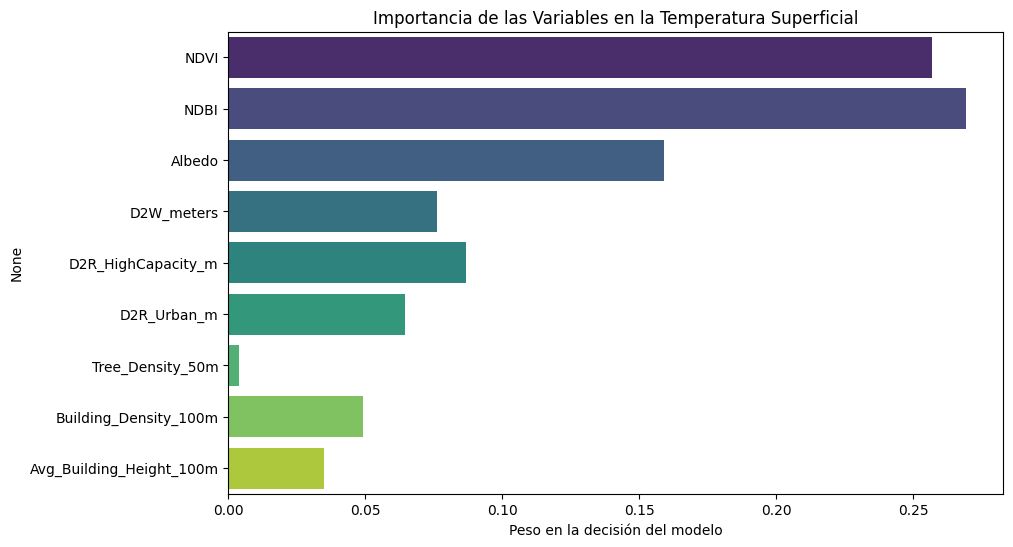

In [10]:
y_pred = mejor_modelo_final_RandomForest.predict(X_test_scaled)

print("--- MÉTRICAS FINALES EN TEST ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} °C")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} °C")

importancias = mejor_modelo_final_RandomForest.feature_importances_
nombres_variables = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=nombres_variables, palette="viridis")
plt.title("Importancia de las Variables en la Temperatura Superficial")
plt.xlabel("Peso en la decisión del modelo")
plt.show()

In [11]:
os.makedirs(os.path.join("..", "models"), exist_ok=True)

ruta_modelo = os.path.join("..", "models", "rf_sevilla_temperatura_v1.pkl")
ruta_scaler = os.path.join("..", "models", "rf_sevilla_temperatura_v1_scaler.pkl")

ruta_modelo_firebase = os.path.join("..", "firebase_functions","functions","models", "rf_sevilla_temperatura_v1.pkl")
ruta_scaler_firebase = os.path.join("..", "firebase_functions","functions","models", "rf_sevilla_temperatura_v1_scaler.pkl")

# Guardamos el modelo
joblib.dump(mejor_modelo_final_RandomForest, ruta_modelo)
joblib.dump(mejor_modelo_final_RandomForest, ruta_modelo_firebase)

joblib.dump(scaler, ruta_scaler)
joblib.dump(scaler, ruta_scaler_firebase)

print(f"✅ ¡Modelo guardado de forma segura en {ruta_modelo}!")

✅ ¡Modelo guardado de forma segura en ../models/rf_sevilla_temperatura_v1.pkl!


In [12]:
print("Iniciando Grid Search para el modelo ganador XGBoost...")

modelo_ganador = XGBRegressor(random_state=42, verbose=-1)

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10, -1],
    'num_leaves': [31, 63, 127]
}

grid_search = GridSearchCV(
    estimator=modelo_ganador,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}")
mejor_modelo_final_XGBoost = grid_search.best_estimator_

Iniciando Grid Search para el modelo ganador XGBoost...
Fitting 3 folds for each of 81 candidates, totalling 243 fits


/Users/mbarrera/uhi-sevilla-ml/venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [01:42:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "num_leaves", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mbarrera/uhi-sevilla-ml/venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [01:42:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "num_leaves", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mbarrera/uhi-sevilla-ml/venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [01:42:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "num_leaves", "verbose" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/mbarrera/uhi-sevilla-ml/venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [01:42:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "num_leaves", "v


Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 500, 'num_leaves': 31}


--- MÉTRICAS FINALES EN TEST ---
R2 Score: 0.8322
RMSE: 1.6333 °C
MAE: 1.1495 °C


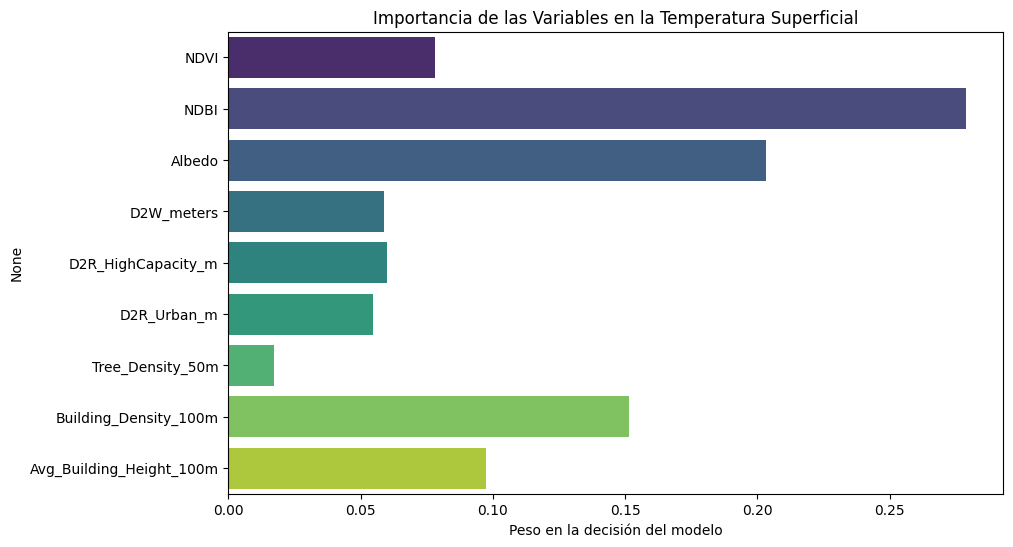

In [13]:
y_pred = mejor_modelo_final_XGBoost.predict(X_test_scaled)

print("--- MÉTRICAS FINALES EN TEST ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} °C")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} °C")

importancias = mejor_modelo_final_XGBoost.feature_importances_
nombres_variables = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=nombres_variables, palette="viridis")
plt.title("Importancia de las Variables en la Temperatura Superficial")
plt.xlabel("Peso en la decisión del modelo")
plt.show()

In [14]:
os.makedirs("models", exist_ok=True)

# Ruta donde guardaremos el modelo ganador
ruta_modelo = os.path.join("..", "models", "xgboost_sevilla_temperatura_v1.pkl")
ruta_scaler = os.path.join("..", "models", "xgboost_sevilla_temperatura_v1_scaler.pkl")

ruta_modelo_firebase = os.path.join("..", "firebase_functions","functions","models", "xgboost_sevilla_temperatura_v1.pkl")
ruta_scaler_firebase = os.path.join("..", "firebase_functions","functions","models", "xgboost_sevilla_temperatura_v1_scaler.pkl")

# Guardamos el modelo
joblib.dump(mejor_modelo_final_XGBoost, ruta_modelo)
joblib.dump(mejor_modelo_final_XGBoost, ruta_modelo_firebase)

joblib.dump(scaler, ruta_scaler)
joblib.dump(scaler, ruta_scaler_firebase)

print(f"¡Modelo guardado de forma segura en {ruta_modelo}!")

¡Modelo guardado de forma segura en ../models/xgboost_sevilla_temperatura_v1.pkl!


In [15]:
inicio = time.time()
xgb_preds = mejor_modelo_final_XGBoost.predict(X_test_scaled)
fin = time.time()
print(f"XGBoost tardó: {fin - inicio:.4f} segundos")

inicio = time.time()
rf_preds = mejor_modelo_final_RandomForest.predict(X_test_scaled)
fin = time.time()
print(f"Random Forest tardó: {fin - inicio:.4f} segundos")

XGBoost tardó: 0.2212 segundos
Random Forest tardó: 0.8119 segundos


In [17]:
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_preds)

# --- Métricas para Random Forest ---
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

# --- Crear una tabla comparativa ---
resultados = pd.DataFrame({
    'Modelo': ['XGBoost', 'Random Forest'],
    'MAE': [xgb_mae, rf_mae],
    'MSE': [xgb_mse, rf_mse],
    'RMSE': [xgb_rmse, rf_rmse],
    'R²': [xgb_r2, rf_r2]
})

print(resultados)

          Modelo       MAE       MSE      RMSE        R²
0        XGBoost  1.149469  2.667724  1.633317  0.832220
1  Random Forest  1.319533  3.420257  1.849394  0.784892


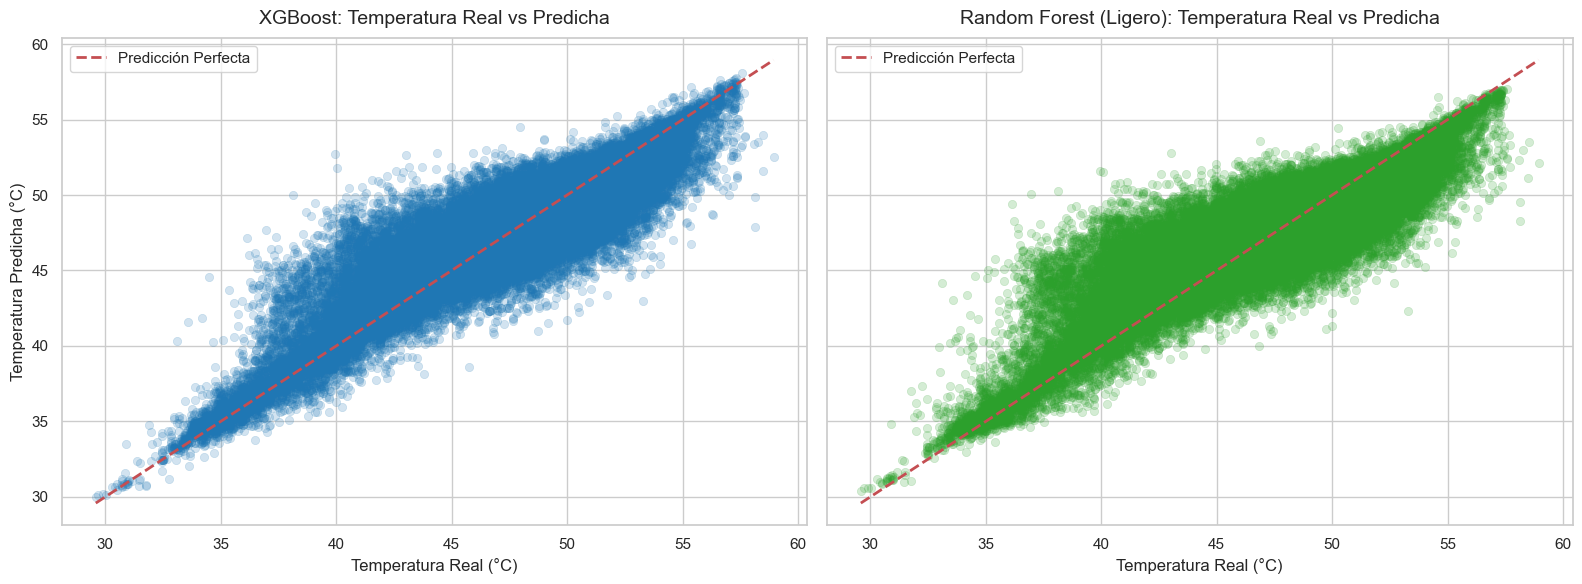

In [16]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
min_val = min(y_test.min(), xgb_preds.min(), rf_preds.min())
max_val = max(y_test.max(), xgb_preds.max(), rf_preds.max())

# --- Panel 1: XGBoost ---
sns.scatterplot(x=y_test, y=xgb_preds, ax=axes[0], alpha=0.2, color="#1f77b4", edgecolor=None)
axes[0].plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label="Predicción Perfecta")
axes[0].set_title('XGBoost: Temperatura Real vs Predicha', fontsize=14, pad=10)
axes[0].set_xlabel('Temperatura Real (°C)', fontsize=12)
axes[0].set_ylabel('Temperatura Predicha (°C)', fontsize=12)
axes[0].legend()

# --- Panel 2: Random Forest ---
sns.scatterplot(x=y_test, y=rf_preds, ax=axes[1], alpha=0.2, color="#2ca02c", edgecolor=None)
axes[1].plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label="Predicción Perfecta")
axes[1].set_title('Random Forest (Ligero): Temperatura Real vs Predicha', fontsize=14, pad=10)
axes[1].set_xlabel('Temperatura Real (°C)', fontsize=12)
axes[1].legend()

# Ajustar el layout y mostrar
plt.tight_layout()
plt.show()

# Reflexiones sobre los parametros de entrenamiento

Se ha decidio limitar la profundida maxima del modelo a la hora de entrenarlo, de no hacerlo, el modelo crecia y crecia siendo muy pesado y teniendo un alto sobreajuste. Al limitarle esto, obligamos al modelo a aprender patrones en lugar de memorizar todos los datos. 

# Conclusiones

Una vez los modelos generados, los hemos guardado en la carpeta models, y tambien en el proyecto de Firebase functions, para que al subir los endpoint se suba el modelo.
Tambien guardamos el escalador, ya que el modelo lo necesita para saber que escala aplicar a los datos de entrada.

Respecto a los resultado y la elección final del modelo: aunque con ambos modelos hemos conseguido resultados muy similares, El XGBoos tiene ligeramente mejores resultados, dando un error medio de 1.63 grados centigrados. Teniendo en cuenta, que dos termometros en una misma calle, uno a la sombra y otro al sol, arrojaran diferencias mayores, podemos concluir que a priori es un resultado aceptable. 

Hay otro detalle que nos hace decantarnos por el XGBoost, una vez guardado el modelo, ocupa apenas 24 MB, sin embargo el RandomForest ocupa poco mas de 700MB. 

Otro detalle que suma puntos, aunque esta relacionado con su tamaño, XGBoost tarda 0.2212 segundos en responder por 0.8119 segundos del Random Forest.

Teniendo en cuenta que la idea es ejecutar esto en un servidor, vamos a optar por el XGBoost ya que es muchisimo mas liviano y cualquier servidor por muy poca RAM que tenga debe soportarlo con creces.

# Representaciones del modelo ganador XGBoost

## Predicciones vs Valores Reales

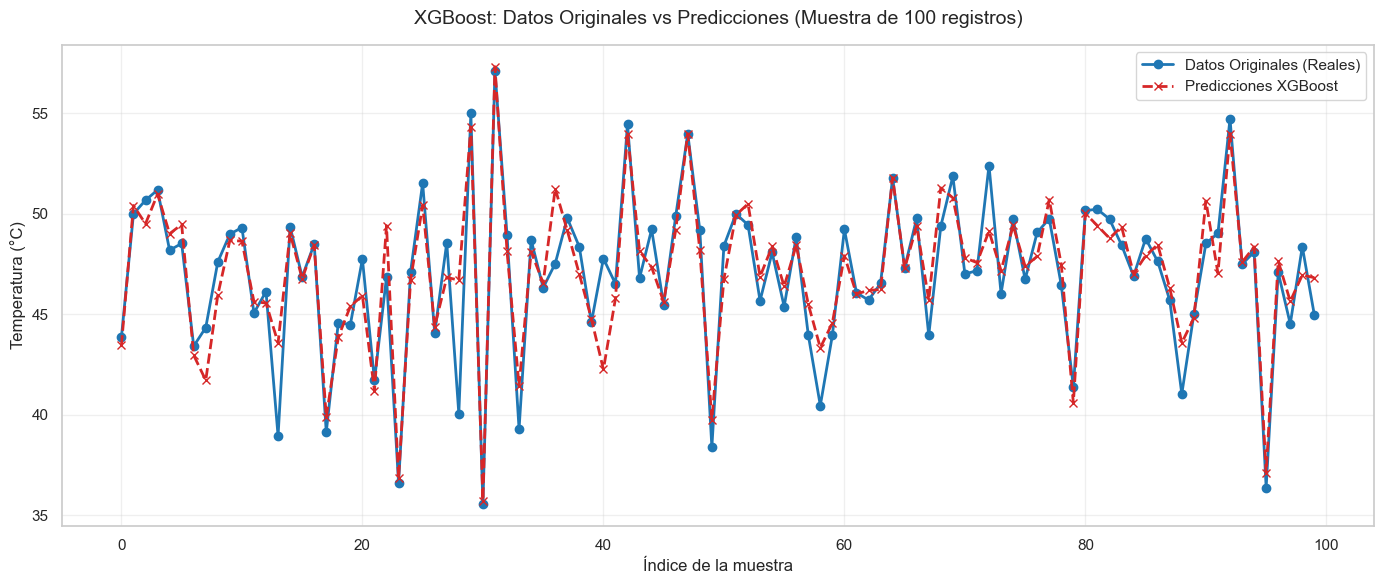

In [18]:
muestra = 100
eje_x = range(len(y_test[:muestra]))

plt.figure(figsize=(14, 6))
# Datos originales (Reales) en azul continuo
plt.plot(eje_x, y_test[:muestra], label="Datos Originales (Reales)", color="#1f77b4", marker='o', linewidth=2)
# Predicciones del modelo en rojo discontinuo
plt.plot(eje_x, xgb_preds[:muestra], label="Predicciones XGBoost", color="#d62728", linestyle="--", marker='x', linewidth=2)

plt.title('XGBoost: Datos Originales vs Predicciones (Muestra de 100 registros)', fontsize=14, pad=15)
plt.xlabel('Índice de la muestra', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Importancia de las Variables

<Figure size 1000x600 with 0 Axes>

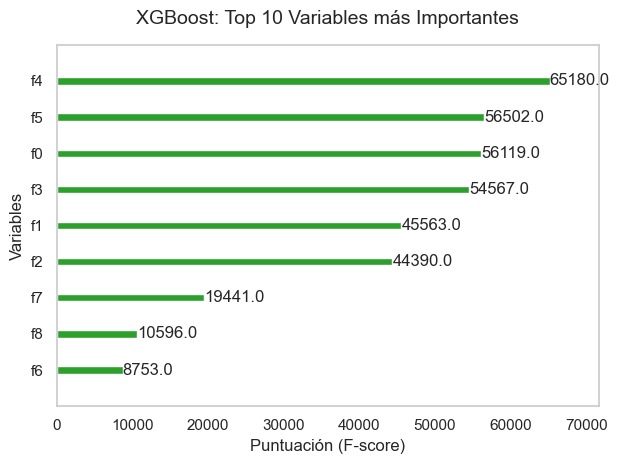

In [20]:
plt.figure(figsize=(10, 6))
# Se asume que tu modelo se llama mejor_modelo_final_XGBoost
ax = plot_importance(mejor_modelo_final_XGBoost, max_num_features=10, color="#2ca02c", grid=False)

plt.title('XGBoost: Top 10 Variables más Importantes', fontsize=14, pad=15)
plt.xlabel('Puntuación (F-score)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

# Pruebas, despliegue y mejora del modelo

El modelo se ha subido a Huggin Face Hub: https://huggingface.co/MiguelBarrera/testtfmmigue/tree/main

Se ha buscado en huggin face modelos similares, se ha encontrado uno ibm-granite/granite-geospatial-land-surface-temperature pero no es posible realizar una comparacion ya que es un modelo de vision, no tabular como el nuestro. Habria que descargar datos satelitales para darselos al modelo. Se intenta hacer una prueba pasandole datos tiif satelitales pero ni con las CPU de Colab se consigue avanzar, se requiere mucha mas potencia. 